In [3]:
import os,sys
import math
import numpy as np
import pandas as pd
import dask.dataframe as dd
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import confusion_matrix, cohen_kappa_score, roc_curve, auc
from datetime import timedelta



In [4]:
df1 = dd.read_parquet('/root/data/rrr/integrated_weather_dataset/data/integrated/parquet_fixed/2017.parquet')
pdf1 = df1.compute()


In [5]:
pdf1


,Timestamp,Site,Latitude,Longitude,ZWD,Wet Gradient North,Wet Gradient East,IVT,Rutz_Label_exact,IVT_approx,Rutz_Label_approx,Guan_Label_exact,Guan_Label_approx,Precipitation_Label_exact,Precipitation_Label_approx,ffw
0,2017-10-05 05:00:00.000003,P563,35.418669,-119.421165,59.9,0.34,-0.50,NaN,NaN,51.666222,0.0,NaN,0.0,NaN,0.0,0
1,2017-01-01 00:00:00.000000,7ODM,34.116407,-117.093192,86.7,0.48,0.76,139.366989,0.0,139.366989,0.0,0.0,0.0,0.0,0.0,0
2,2017-05-20 20:20:00.000003,P570,35.667348,-118.260038,75.4,-0.01,-0.17,NaN,NaN,23.633263,0.0,NaN,0.0,NaN,0.0,0
3,2017-01-01 00:05:00.000000,7ODM,34.116407,-117.093192,86.9,0.51,0.77,NaN,NaN,139.366989,0.0,NaN,0.0,NaN,0.0,0
4,2017-05-20 20:25:00.000003,P570,35.667348,-118.260038,75.5,-0.03,-0.19,NaN,NaN,23.633263,0.0,NaN,0.0,NaN,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1363547,2017-05-20 20:05:00.000003,P570,35.667348,-118.260038,75.6,0.06,-0.10,NaN,NaN,23.633263,0.0,NaN,0.0,NaN,0.0,0
1363548,2017-10-05 04:50:00.000003,P563,35.418669,-119.421165,59.4,0.31,-0.49,NaN,NaN,51.666222,0.0,NaN,0.0,NaN,0.0,0
1363549,2017-05-20 20:10:00.000003,P570,35.667348,-118.260038,75.5,0.04,-0.12,NaN,NaN,23.633263,0.0,NaN,0.0,NaN,0.0,0
1363550,2017-05-20 20:15:00.000003,P570,35.667348,-118.260038,75.4,0.01,-0.15,NaN,NaN,23.633263,0.0,NaN,0.0,NaN,0.0,0


In [6]:
df2 = dd.read_csv('/root/data/rrr/integrated_weather_dataset/inf_results_2017_2.csv')

In [7]:
pdf2 = df2.compute()


In [8]:
pdf2

,Timestamp,Site,Latitude,Longitude,ZWD,Label,Prediction
0,2017-01-08 02:34:59.999998,7ODM,34.116407,-117.093192,136.7,1,0.891046
1,2017-01-08 02:39:59.999998,7ODM,34.116407,-117.093192,136.8,1,0.890664
2,2017-01-08 02:44:59.999998,7ODM,34.116407,-117.093192,136.7,1,0.890232
3,2017-01-08 02:49:59.999998,7ODM,34.116407,-117.093192,136.7,1,0.889847
4,2017-01-08 02:54:59.999998,7ODM,34.116407,-117.093192,136.8,1,0.889474
...,...,...,...,...,...,...,...
767934,2017-12-30 23:35:00.000001,YUHG,32.647566,-115.922234,21.3,0,0.055644
767935,2017-12-30 23:40:00.000001,YUHG,32.647566,-115.922234,21.4,0,0.055705
767936,2017-12-30 23:45:00.000001,YUHG,32.647566,-115.922234,21.5,0,0.055754
767937,2017-12-30 23:50:00.000001,YUHG,32.647566,-115.922234,21.6,0,0.055721


In [9]:
import random
unique_sites = list(set(pdf2['Site'].tolist()))
random_sites = unique_sites[:10]


In [10]:
random_sites

['P476',
 'P621',
 'P620',
 'VTIS',
 'KNOL',
 'RHCG',
 'P066',
 'P465',
 'P740',
 'NHRG']

In [11]:
dff1 = pdf1[pdf1['Site'].isin(random_sites)]
dff2 = pdf2[pdf2['Site'].isin(random_sites)]


In [12]:
dff2['Timestamp'] = pd.to_datetime(dff2['Timestamp'], format='mixed')

dff1['Timestamp'] = pd.to_datetime(dff1['Timestamp'], format='mixed')

merged_df = pd.merge(
    dff2,
    dff1[['Timestamp', 'ZWD', 'Wet Gradient North', 'Wet Gradient East', 'Precipitation_Label_approx', 'ffw']],
    on='Timestamp',
    how='left'
)



/tmp/ipykernel_469/2172863736.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dff2['Timestamp'] = pd.to_datetime(dff2['Timestamp'], format='mixed')
/tmp/ipykernel_469/2172863736.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dff1['Timestamp'] = pd.to_datetime(dff1['Timestamp'], format='mixed')


In [13]:
merged_df

,Timestamp,Site,Latitude,Longitude,ZWD_x,Label,Prediction,ZWD_y,Wet Gradient North,Wet Gradient East,Precipitation_Label_approx,ffw
0,2017-01-08 02:34:59.999998,KNOL,37.659118,-118.979171,70.7,1,0.938065,70.7,-0.94,-0.84,3.37,0
1,2017-01-08 02:34:59.999998,KNOL,37.659118,-118.979171,70.7,1,0.938065,123.2,0.31,0.35,0.00,0
2,2017-01-08 02:34:59.999998,KNOL,37.659118,-118.979171,70.7,1,0.938065,125.1,0.30,-0.49,0.00,0
3,2017-01-08 02:34:59.999998,KNOL,37.659118,-118.979171,70.7,1,0.938065,63.1,-1.22,-0.54,15.66,0
4,2017-01-08 02:34:59.999998,KNOL,37.659118,-118.979171,70.7,1,0.938065,144.0,0.17,-0.34,0.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...
10066768,2017-12-30 23:55:00.000001,VTIS,33.712638,-118.293819,29.5,0,0.055602,17.6,-0.05,-0.11,0.00,0
10066769,2017-12-30 23:55:00.000001,VTIS,33.712638,-118.293819,29.5,0,0.055602,14.6,0.11,-0.35,0.00,0
10066770,2017-12-30 23:55:00.000001,VTIS,33.712638,-118.293819,29.5,0,0.055602,16.4,0.54,-0.18,0.00,0
10066771,2017-12-30 23:55:00.000001,VTIS,33.712638,-118.293819,29.5,0,0.055602,30.0,-0.93,0.12,0.00,0


In [14]:
merged_df['Prediction_Final'] = (merged_df['Prediction'] >= 0.50).astype(int)

In [15]:
merged_df

,Timestamp,Site,Latitude,Longitude,ZWD_x,Label,Prediction,ZWD_y,Wet Gradient North,Wet Gradient East,Precipitation_Label_approx,ffw,Prediction_Final
0,2017-01-08 02:34:59.999998,KNOL,37.659118,-118.979171,70.7,1,0.938065,70.7,-0.94,-0.84,3.37,0,1
1,2017-01-08 02:34:59.999998,KNOL,37.659118,-118.979171,70.7,1,0.938065,123.2,0.31,0.35,0.00,0,1
2,2017-01-08 02:34:59.999998,KNOL,37.659118,-118.979171,70.7,1,0.938065,125.1,0.30,-0.49,0.00,0,1
3,2017-01-08 02:34:59.999998,KNOL,37.659118,-118.979171,70.7,1,0.938065,63.1,-1.22,-0.54,15.66,0,1
4,2017-01-08 02:34:59.999998,KNOL,37.659118,-118.979171,70.7,1,0.938065,144.0,0.17,-0.34,0.00,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10066768,2017-12-30 23:55:00.000001,VTIS,33.712638,-118.293819,29.5,0,0.055602,17.6,-0.05,-0.11,0.00,0,0
10066769,2017-12-30 23:55:00.000001,VTIS,33.712638,-118.293819,29.5,0,0.055602,14.6,0.11,-0.35,0.00,0,0
10066770,2017-12-30 23:55:00.000001,VTIS,33.712638,-118.293819,29.5,0,0.055602,16.4,0.54,-0.18,0.00,0,0
10066771,2017-12-30 23:55:00.000001,VTIS,33.712638,-118.293819,29.5,0,0.055602,30.0,-0.93,0.12,0.00,0,0


In [16]:
merged_df[merged_df['ffw'] == 1]

,Timestamp,Site,Latitude,Longitude,ZWD_x,Label,Prediction,ZWD_y,Wet Gradient North,Wet Gradient East,Precipitation_Label_approx,ffw,Prediction_Final
36462,2017-01-20 18:34:59.999997,KNOL,37.659118,-118.979171,-21.0,0,0.187714,37.7,-0.68,-1.11,4.27,1,0
36472,2017-01-20 18:39:59.999997,KNOL,37.659118,-118.979171,-21.6,0,0.188926,37.4,-0.64,-1.11,4.27,1,0
36482,2017-01-20 18:44:59.999997,KNOL,37.659118,-118.979171,-22.0,0,0.189837,37.1,-0.60,-1.11,4.27,1,0
36492,2017-01-20 18:49:59.999997,KNOL,37.659118,-118.979171,-22.2,0,0.190448,36.6,-0.56,-1.11,0.00,1,0
36502,2017-01-20 18:54:59.999997,KNOL,37.659118,-118.979171,-22.5,0,0.190543,36.0,-0.52,-1.11,0.00,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9742985,2017-09-09 03:20:00.000000,VTIS,33.712638,-118.293819,122.9,0,0.391424,154.8,1.43,0.13,0.00,1,0
9742994,2017-09-09 03:25:00.000000,VTIS,33.712638,-118.293819,123.0,0,0.390975,181.8,0.86,0.96,0.00,1,0
9742995,2017-09-09 03:25:00.000000,VTIS,33.712638,-118.293819,123.0,0,0.390975,154.8,1.42,0.10,0.00,1,0
9743004,2017-09-09 03:30:00.000000,VTIS,33.712638,-118.293819,123.0,0,0.390386,181.0,0.91,0.93,0.00,1,0


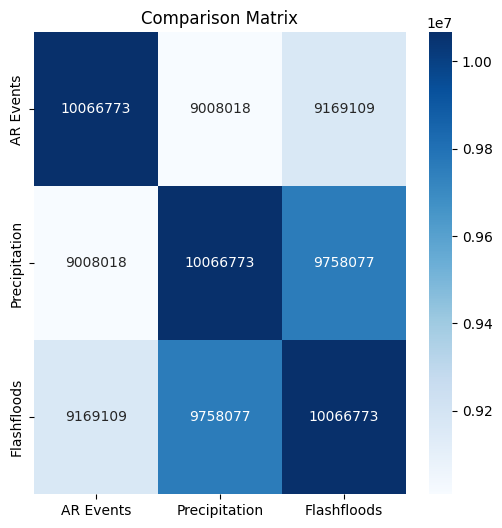

In [17]:
matrix = np.zeros((3, 3), dtype=int)

columns = ['Label', 'Precipitation_Label_approx', 'ffw']

for i, col1 in enumerate(columns):
    for j, col2 in enumerate(columns):
        matrix[i, j] = (merged_df[col1] == merged_df[col2]).sum()


# Plot the 3x3 heatmap
plt.figure(figsize=(6, 6))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['AR Events', 'Precipitation', 'Flashfloods'], yticklabels=['AR Events', 'Precipitation', 'Flashfloods'])
plt.title("Comparison Matrix")
plt.show()


In [18]:
def find_contiguous_runs(series):
    runs = []
    start_idx = None
    for idx, value in enumerate(series):
        if value == 1 and start_idx is None: 
            start_idx = idx
        elif value == 0 and start_idx is not None:
            runs.append((start_idx, idx - 1))
            start_idx = None
    if start_idx is not None: 
        runs.append((start_idx, len(series) - 1))
    return runs

label_runs = find_contiguous_runs(merged_df['Label'])
precipitation_runs = find_contiguous_runs(merged_df['Precipitation_Label_approx'])
ffw_runs = find_contiguous_runs(merged_df['ffw'])

Atleast one timestamp
def runs_overlap(run1, run2):
    start1, end1 = run1
    start2, end2 = run2
    return max(start1, start2) <= min(end1, end2)


# def runs_overlap(run1, run2):
#     start1, end1 = run1
#     start2, end2 = run2
#     overlap_start = max(start1, start2)
#     overlap_end = min(end1, end2)
#     overlap_length = max(0, overlap_end - overlap_start + 1)
    
#     run1_length = end1 - start1 + 1
#     run2_length = end2 - start2 + 1
    
#     return overlap_length >= 0.5 * run1_length or overlap_length >= 0.5 * run2_length


matrix = np.zeros((3, 3), dtype=int)

matrix[0, 0] = count_overlaps(label_runs, label_runs)
matrix[0, 1] = count_overlaps(label_runs, precipitation_runs)
matrix[0, 2] = count_overlaps(label_runs, ffw_runs)
matrix[1, 0] = count_overlaps(precipitation_runs, label_runs)
matrix[1, 1] = count_overlaps(precipitation_runs, precipitation_runs)
matrix[1, 2] = count_overlaps(precipitation_runs, ffw_runs) 
matrix[2, 0] = count_overlaps(ffw_runs, label_runs)
matrix[2, 1] = count_overlaps(ffw_runs, precipitation_runs)
matrix[2, 2] = count_overlaps(ffw_runs, ffw_runs) 

plt.figure(figsize=(6, 6))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['AR Events', 'Precipitation', 'Flashfloods'], 
            yticklabels=['AR Events', 'Precipitation', 'Flashfloods'])
plt.title("Event Agreement Matrix")
plt.show()



SyntaxError: invalid syntax (3427452293.py, line 18)

In [ ]:
start_date = '2017-05-16'
end_date = '2017-05-19'

start_date = pd.to_datetime(start_date)
end_date = pd.to_datetime(end_date)

In [ ]:
for site in random_sites:
    site_data = merged_df[(merged_df['Site'] == site) & 
                          (merged_df['Timestamp'] >= start_date) & 
                          (merged_df['Timestamp'] <= end_date)]

    
    plt.figure(figsize=(15, 6))
    
    for column in ['Label', 'Prediction_Final', 'Precipitation_Label_approx', 'ffw']:
        plt.scatter(site_data[site_data[column] == 1]['Timestamp'], 
                    [column] * len(site_data[merged_df[column] == 1]), 
                    label=column)
    
    plt.xlabel('Timestamp')
    plt.ylabel('Columns')
    plt.title(f'2017 - {site}')
    plt.legend()
    plt.grid(True)
    plt.show()

